## QAOA Plots
This notebook contains all QAOA-related plots presented in the paper.
The computation of the QAOA angles is performed in `ssh_qaoa_calc_parameters.py`, following the procedure below:

```text 
for each N:
    for each load:
        for each p:
            randomly select 1 out of 30 instances  # introduces stochasticity
            load the selected instance
            train QAOA parameters
            save both parameters and the corresponding instance
        end for
    end for
end for
```
where $p \in \{16, 32, 64, 128, 256\}$ refers to $p_0$, the initial depth parameter used in the iterative interpolation scheme.
Due to poor optimization performance, results for $p=256$ were excluded from further analysis.
In combination with the brute-force solutions of the optimization problem (computed via `brute_force.py`), the final results used in the paper are generated by running `ssh_qaoa_calc_results.py`.
The remainder of this notebook focuses on loading these precomputed results and visualizing them.

### $\text{TTS}^*$ Plot

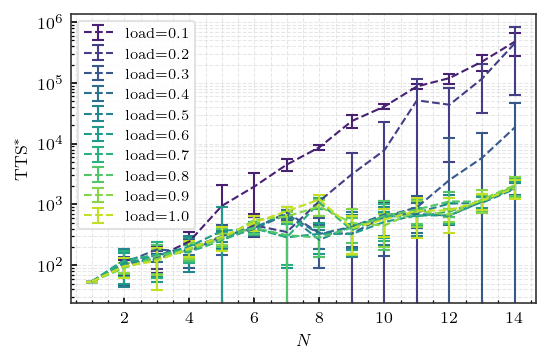

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import pickle
from collections import defaultdict 
from styling import set_my_style

# auxilary function
def load_results(filename="results.pkl"):
    with open(filename, "rb") as f:
        return pickle.load(f)
# load data
# format: tts_star_results[cs][load][instance], cs: candidate_space 2**N
tts_star_results = load_results('data/results/tts_star_qaoa.pkl')

# prepare data for plotting
tts_star_plot_results = defaultdict(lambda: defaultdict(dict))
for cs in sorted(tts_star_results): 
    for load in sorted(tts_star_results[cs]):
        instance_scores = []
        for instance in sorted(tts_star_results[cs][load]):
            instance_scores.append(tts_star_results[cs][load][instance])
        tts_star_plot_results[cs][load] = { # average over instances and take stds for errorbars 
            'mean': np.mean(instance_scores),
            'std': np.std(instance_scores)
        }
# change data structure to make plotting more convenient
cs_vals = sorted(tts_star_plot_results.keys())
load_vals = sorted({
    load for cs in cs_vals for load in tts_star_plot_results[cs]
})

set_my_style(use_latex=True)
colors = sns.color_palette("viridis", len(load_vals))

for i, load in enumerate(load_vals):
    xs, means, std = [], [], [] # x values xs
    for cs in cs_vals:
        if 'mean' in tts_star_plot_results[cs].get(load, {}): # prevents bugs 
            xs.append(int(np.log2(cs))) # to get N
            means.append(tts_star_plot_results[cs][load]['mean'])
            std.append(tts_star_plot_results[cs][load]['std'])
    if xs: # only plot excisting data
        plt.errorbar(xs, means, std, 
        label=f'load={load}', 
        capsize=3, 
        ls='--',
        color=colors[i])
plt.xlabel(r'$N$')
plt.ylabel(r'$\mathrm{TTS}^*$')
plt.yscale('log')
plt.legend()
plt.show()

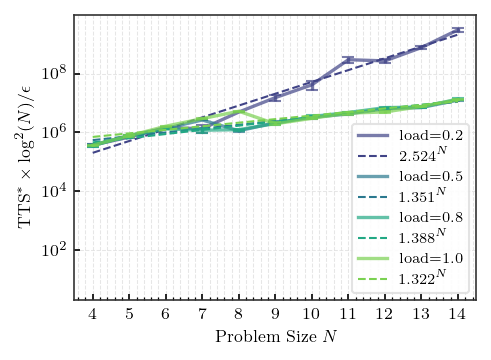

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
from collections import defaultdict

from plotting import log_plot_per_load_factor_with_fits
from styling import set_my_style

# --- Load data ---
def load_results(filename="results.pkl"):
    with open(filename, "rb") as f:
        return pickle.load(f)

tts_star_results = load_results('local/results/tts_star_qaoa.pkl')

# --- Aggregate mean/std ---
tts_star_plot_results = defaultdict(lambda: defaultdict(dict))
epsilon = 1e-3
for cs in sorted(tts_star_results):
    N = int(np.log2(cs))
    for load in sorted(tts_star_results[cs]):
        instance_scores = [
            tts_star_results[cs][load][instance]*np.log(N)**2/epsilon
            for instance in sorted(tts_star_results[cs][load])
        ]
        tts_star_plot_results[cs][load] = {
            'mean': np.mean(instance_scores),
            'std': np.std(instance_scores)
        }

# --- Prepare arrays for plotting ---
cs_vals = sorted(tts_star_plot_results.keys())
N_vals = np.array([int(np.log2(cs)) for cs in cs_vals])

load_vals = sorted({
    load for cs in cs_vals for load in tts_star_plot_results[cs]
})

# optionally filter loads (like you did before)
load_vals = [l for l in load_vals if l in [0.2, 0.5, 0.8, 1.0]]

means = []
stds = []

for load in load_vals:
    mean_row = []
    std_row = []
    for cs in cs_vals:
        entry = tts_star_plot_results[cs].get(load, {})
        mean_row.append(entry.get('mean', np.nan))
        std_row.append(entry.get('std', np.nan))
    means.append(mean_row)
    stds.append(std_row)

means = np.array(means)
stds = np.array(stds)

mask = N_vals >= 4

means = means[:, mask]
stds = stds[:, mask]
N_vals = N_vals[mask]

stds_err = stds / np.sqrt(30)

# --- Plot ---
set_my_style(use_latex=True)
palette = sns.color_palette("viridis", len(load_vals))
fig, ax = plt.subplots(figsize=(3.375, 2.5))  # width, height in inches

log_plot_per_load_factor_with_fits(
    ax=ax,
    xs=N_vals,
    means=means,
    stds=stds_err,
    load_factors=load_vals,
    labels=(r'$\mathrm{TTS}^* \times \log^2(N)/ \epsilon$', r'Problem Size $N$'),
    palette=palette,
    set_xticks=True
)

plt.tight_layout()
plt.savefig("qaoa_tts_loads.pdf", bbox_inches="tight")  # <-- save here
plt.show()

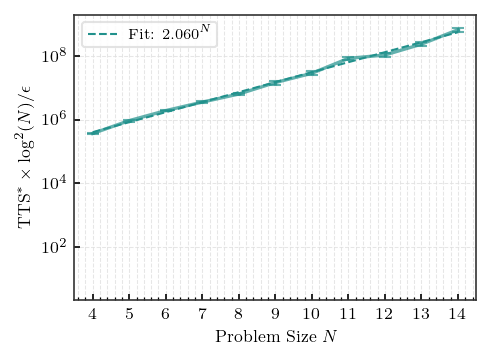

In [3]:
# --- Compute average over ALL loads (independent of filtered plot) ---

mean_all = []
std_all = []
epsilon = 1e-3

for cs in cs_vals:
    N = int(np.log2(cs))
    all_scores = []
    for load in tts_star_results[cs]:  # <-- ALL loads here
        for instance in tts_star_results[cs][load]:
            all_scores.append(tts_star_results[cs][load][instance]*np.log(N)**2/epsilon)

    mean_all.append(np.mean(all_scores))
    std_all.append(np.std(all_scores))

mean_all = np.array(mean_all)
std_all = np.array(std_all)


# --- Apply SAME N >= 4 filter as above ---
start_idx = 3
mean_all = mean_all[start_idx:]
std_all = std_all[start_idx:]

std_all_err = std_all / np.sqrt(10*30) # 10 loads * 30 instances
N_vals_avg = np.array([int(np.log2(cs)) for cs in cs_vals])[start_idx:]

from plotting import log_plot_with_fits

fig, ax = plt.subplots(figsize=(3.375, 2.5))  # width, height in inches

log_plot_with_fits(
    ax=ax,
    xs=N_vals_avg,
    means=mean_all,
    stds=std_all_err,
    labels=(r'$\mathrm{TTS}^* \times \log^2(N)/ \epsilon$', r'Problem Size $N$'),
    palette=[sns.color_palette("viridis", 1)[0]],
    set_xticks=True
)

plt.tight_layout()
plt.savefig("qaoa_tts_average.pdf", bbox_inches="tight")  # <-- save here
plt.show()

### RAAR Plots 
#### RAAR vs. N (multiple p, simulatenously averaged over all loads and instances)

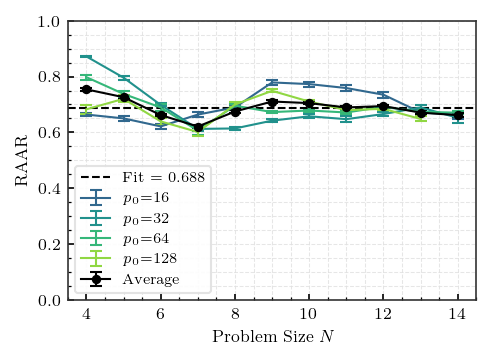

In [ ]:
raar_results = load_results('data/results/raar_qaoa.pkl')

p0_vals = sorted({
    p0 for cs in raar_results
       for load in raar_results[cs]
       for p0 in raar_results[cs][load]
})

# omit p0 = 256
p0_vals = [p0 for p0 in p0_vals if p0 != 256]

colors = sns.color_palette("viridis", len(p0_vals))

fig, ax = plt.subplots(figsize=(3.375, 2.5))

# Individual p0 curves
for i, p0 in enumerate(p0_vals):
    if p0 == 8:
        continue

    xs, means, sems = [], [], []

    for cs in sorted(raar_results.keys()):
        all_values = []

        for load in raar_results[cs]:
            if p0 not in raar_results[cs][load]:
                continue

            vals = list(raar_results[cs][load][p0].values())
            all_values.extend(vals)

        N = int(np.log2(cs))

        if N > 3 and len(all_values) > 0:
            xs.append(N)
            means.append(np.mean(all_values))
            sems.append(np.std(all_values) / np.sqrt(len(all_values)))

    if xs:
        ax.errorbar(
            xs, means, yerr=sems,
            label=r'$p_0$' + f'={p0}',
            capsize=3,
            ls='-',
            color=colors[i]
        )

# Average over all loads and p0 values
xs_av, means_av, sems_av = [], [], []
all_values_global = []

for cs in sorted(raar_results.keys()):
    all_values = []

    for load in raar_results[cs]:
        for p0 in p0_vals:
            if p0 == 8:
                continue
            if p0 not in raar_results[cs][load]:
                continue

            vals = list(raar_results[cs][load][p0].values())
            all_values.extend(vals)
            all_values_global.extend(vals)

    N = int(np.log2(cs))

    if N > 3 and len(all_values) > 1:
        xs_av.append(N)
        means_av.append(np.mean(all_values))
        sems_av.append(np.std(all_values) / np.sqrt(len(all_values)))

# Black average curve
ax.errorbar(
    xs_av, means_av, yerr=sems_av,
    capsize=3,
    ls='-',
    marker='o',
    color='black',
    label='Average'
)

# Fit / overall mean line
overall_mean = np.mean(means_av)

ax.axhline(
    overall_mean,
    linestyle='--',
    color='black',
    label=f'Fit = {overall_mean:.3f}'
)

ax.set_xlabel(r'Problem Size $N$')
ax.set_ylabel('RAAR')
ax.set_ylim(0, 1)
ax.legend()
plt.tight_layout()
plt.savefig("qaoa_RAAR_combined.pdf", bbox_inches="tight")
plt.show()

#### RAAR vs. p

In [5]:

# load parameter files to obtain p
import re 
import os 
from datetime import datetime

# code adapted from ssh_qaoa_calc_results.py
#folder_bf = '/opt/copy/second_run/'
folder_params = 'local/ssh_qaoa_params_v1/'

# -----------------------------
# Filename patterns
# -----------------------------
filename_pattern_bf = re.compile(
    r'^candidate_space_(?P<candidate_space>\d+)_candidates_50_busses_'
    r'(?P<load>\d+\.\d+)_load_factor_'
    r'(?P<timestamp>\d{4}-\d{2}-\d{2}_\d{2}-\d{2}-\d{2})_'
    r'(?P<instance>\d+)\.csv$'
)

filename_pattern_params = re.compile(
    r'^candidate_space_(?P<candidate_space>\d+)_candidates_50_busses_'
    r'(?P<load>\d+\.\d+)_load_factor_'
    r'(?P<timestamp>\d{4}-\d{2}-\d{2}_\d{2}-\d{2}-\d{2})_'
    r'(?P<instance>\d+)_p0_(?P<p>\d+)\.pkl$'
)

# -----------------------------
# Unified parser
# -----------------------------
def parse_filename(filename):
    for pattern, filetype in [
        (filename_pattern_bf, "bf"),
        (filename_pattern_params, "params"),
    ]:
        match = pattern.match(filename)
        if match:
            data = match.groupdict()
            return {
                "type": filetype,
                "candidate_space": int(data["candidate_space"]),
                "load": float(data["load"]),
                "timestamp": datetime.strptime(data["timestamp"], "%Y-%m-%d_%H-%M-%S"),
                "instance": int(data["instance"]),
                "p": int(data["p"]) if "p" in data and data["p"] else None,
                "filename": filename,
            }
    return None

# -----------------------------
# New structure
# -----------------------------
files_dict = {
    "bf": defaultdict(lambda: defaultdict(list)),
    "params": defaultdict(lambda: defaultdict(lambda: defaultdict(list)))
}

# -----------------------------
# Load BF files
# -----------------------------
#for f in os.listdir(folder_bf):
#    parsed = parse_filename(f)
#    if parsed and parsed["type"] == "bf":
#        cs = parsed["candidate_space"]
#        load = parsed["load"]
#        files_dict["bf"][cs][load].append(parsed)

# -----------------------------
# Load PARAM files
# -----------------------------
for f in os.listdir(folder_params):
    parsed = parse_filename(f)
    if parsed and parsed["type"] == "params":
        cs = parsed["candidate_space"]
        load = parsed["load"]
        p = parsed["p"]

        files_dict["params"][cs][load][p].append(parsed)

# -----------------------------
# Sorting
# -----------------------------
def sort_key(parsed):
    return (
        parsed["candidate_space"],
        parsed["load"],
        parsed["instance"],
        parsed["p"] if parsed["p"] is not None else -1,
    )

# sort bf
for cs in files_dict["bf"]:
    for load in files_dict["bf"][cs]:
        files_dict["bf"][cs][load] = sorted(
            files_dict["bf"][cs][load], key=sort_key
        )

# sort params
for cs in files_dict["params"]:
    for load in files_dict["params"][cs]:
        for p in files_dict["params"][cs][load]:
            files_dict["params"][cs][load][p] = sorted(
                files_dict["params"][cs][load][p], key=sort_key
            )

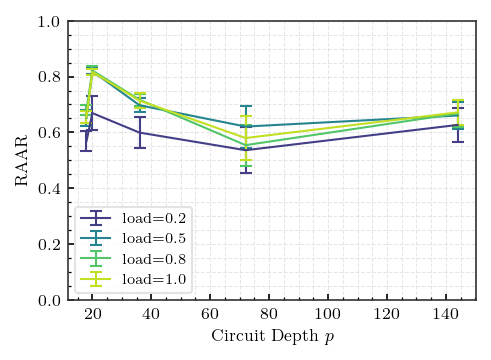

In [ ]:
raar_results = load_results('data/results/raar_qaoa.pkl')

p_vals = defaultdict(lambda: defaultdict(list))

for cs in raar_results:
    for load in raar_results[cs]:
        for p0 in raar_results[cs][load]:
            for instance in raar_results[cs][load][p0]:
                raar = raar_results[cs][load][p0][instance]
                # reconstruct parameter file path
                params_file = files_dict['params'][cs][load][p0][0]['filename']
                full_path = folder_params + params_file
                with open(full_path, 'rb') as f:
                    pkl = pickle.load(f)
                p = len(pkl['gammas'])
                p_vals[load][p].append(raar) 

load_keys = sorted(p_vals.keys())
colors = sns.color_palette("viridis", len(load_keys))
fig, ax = plt.subplots(figsize=(3.375, 2.5))  # width, height in inches


target_loads = [0.2, 0.5, 0.8, 1.0]
for i, load in enumerate(load_keys):
    if load not in target_loads:
        continue
    ps = sorted(p_vals[load].keys())
    ps = [p for p in ps if p < 256 and p >= 16]
    means = [np.mean(p_vals[load][p]) for p in ps]
    stds  = [np.std(p_vals[load][p]) for p in ps]
    stds_err = [s/np.sqrt(30) for s in stds]

    plt.errorbar(
        ps, means, stds_err,
        label=f'load={load}',
        capsize=3,
        ls='-',
        color=colors[i]
    )

plt.xlabel(r'Circuit Depth $p$')
#plt.xscale('log')
plt.ylabel('RAAR')
plt.ylim(0, 1)
plt.legend()
plt.tight_layout()
plt.savefig("qaoa_RAAR_p_loads.pdf", bbox_inches="tight")  # <-- save here
plt.show()

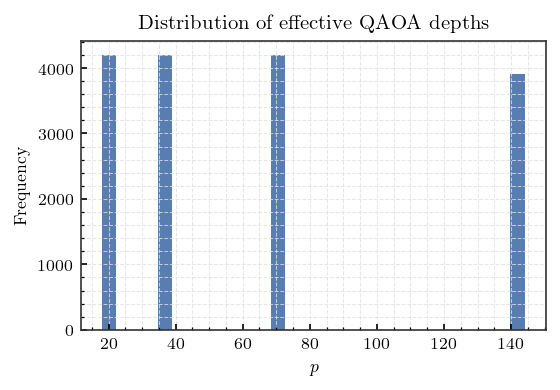

In [7]:
all_ps = []

for load in p_vals:
    for p in p_vals[load]:
        if p < 256 and p >= 16:
            all_ps.extend([p] * len(p_vals[load][p]))
plt.hist(all_ps, bins=30, alpha=0.8)

plt.xlabel(r'$p$')
plt.ylabel('Frequency')
plt.title('Distribution of effective QAOA depths')

#plt.xscale('log')
plt.show()